# Mutual Fund Analytics - EDA Analysis Notebook

This Jupyter Notebook performs detailed Exploratory Data Analysis (EDA) on 40 mutual fund schemes across major AMCs (2022–2026), examining daily NAV performance, AUM trajectories, monthly SIP inflows, category flow dynamics, investor demographics, geographic distribution, industry folio expansion, return correlations, and equity sector exposure.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configure Plotly & Seaborn aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# Connect to database & load fact/dim tables
conn = sqlite3.connect('../bluestock_mf.db' if os.path.exists('../bluestock_mf.db') else 'bluestock_mf.db')
dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)
fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
fact_aum = pd.read_sql("SELECT * FROM fact_aum", conn)
fact_monthly_sip = pd.read_sql("SELECT * FROM fact_monthly_sip", conn)
fact_category_inflows = pd.read_sql("SELECT * FROM fact_category_inflows", conn)
fact_industry_folio = pd.read_sql("SELECT * FROM fact_industry_folio", conn)
fact_transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
fact_portfolio_holdings = pd.read_sql("SELECT * FROM fact_portfolio_holdings", conn)

print("Database tables loaded successfully.")


Database tables loaded successfully.


## 1. NAV Trend Analysis (2022–2026)

In [2]:
# Chart 1: Daily NAV Trend Analysis for All 40 Schemes
nav_merged = fact_nav.merge(dim_fund[['amfi_code', 'scheme_name', 'sub_category']], on='amfi_code')
fig1 = px.line(
    nav_merged,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend Analysis for All 40 Schemes (2022–2026)',
    labels={'date': 'Date', 'nav': 'Net Asset Value (INR)', 'scheme_name': 'Scheme Name'}
)
fig1.update_layout(showlegend=False, template='plotly_white', height=600)
fig1.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.15, line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left",
    annotation=dict(font_size=14, font_color="green")
)
fig1.add_vrect(
    x0="2024-06-01", x1="2024-10-31",
    fillcolor="red", opacity=0.15, line_width=0,
    annotation_text="2024 Market Corrections", annotation_position="top right",
    annotation=dict(font_size=14, font_color="red")
)
fig1.show()


### Key Finding 1: NAV Growth & Market Cycles
Scheme NAVs experienced strong multi-year compounding during the 2023 bull market followed by brief 5-10% drawdowns during the 2024 market corrections.  
*(Supporting Chart: Chart 1 - Daily NAV Trend Analysis for All 40 Schemes)*

## 2. AUM Growth & Market Leadership

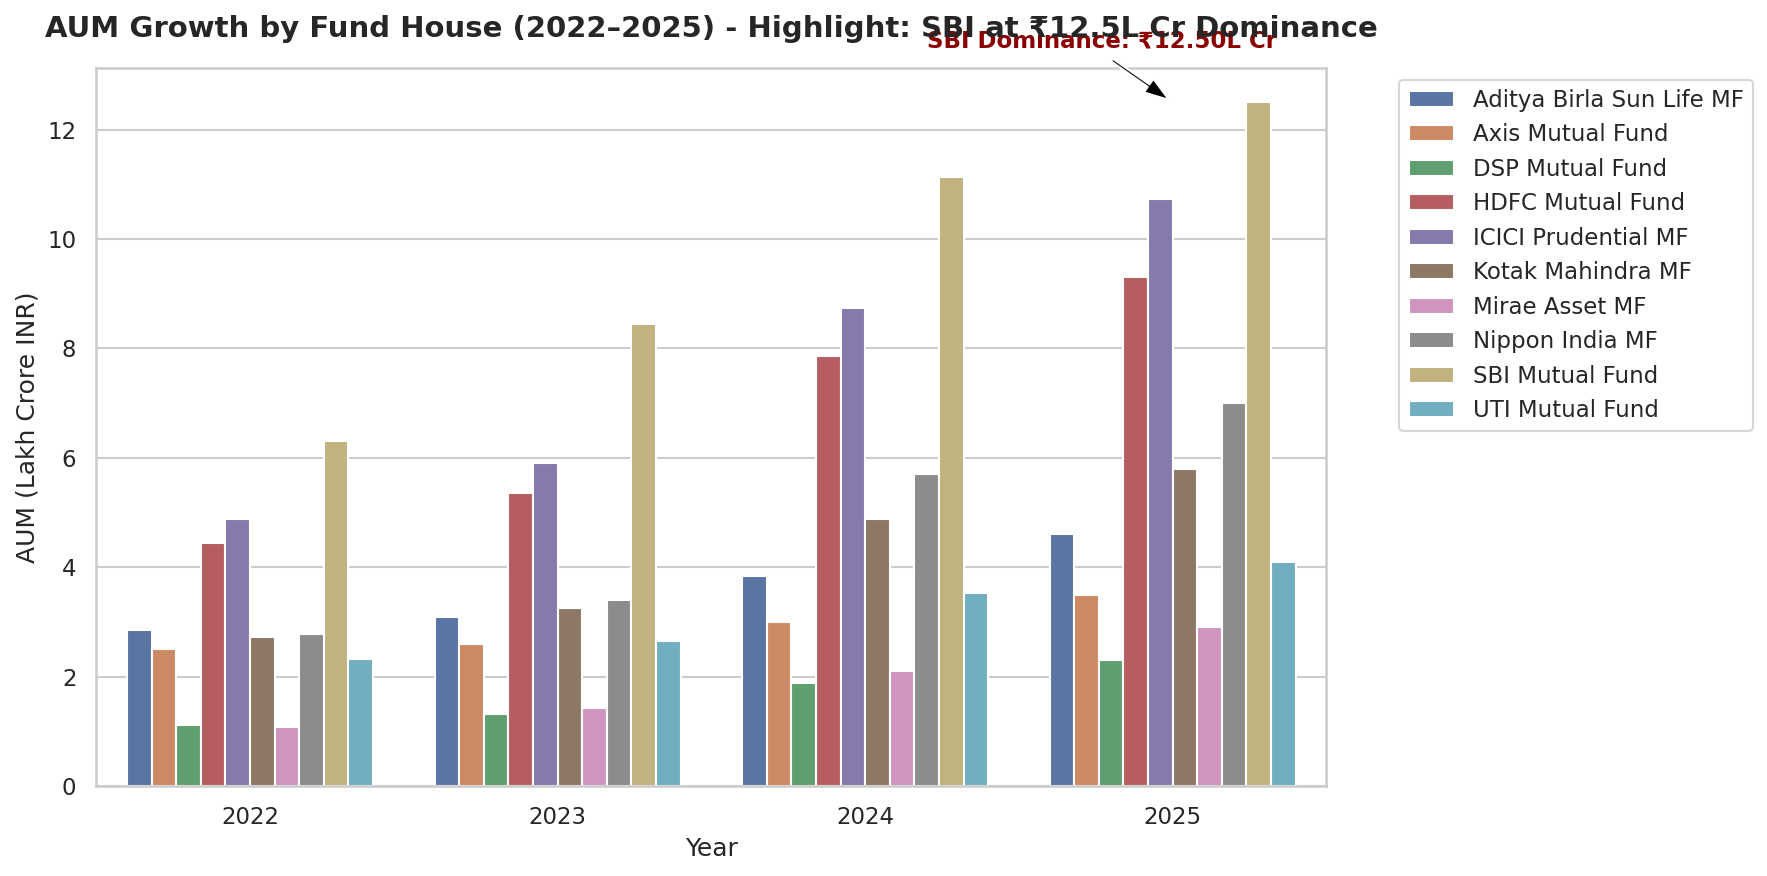

In [3]:
# Chart 2: Grouped Bar Chart of AUM Growth by Fund House (2022–2025)
fact_aum['date'] = pd.to_datetime(fact_aum['date'])
fact_aum['year'] = fact_aum['date'].dt.year
aum_yearly = fact_aum.groupby(['year', 'fund_house'])['aum_lakh_crore'].max().reset_index()

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(
    data=aum_yearly,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house',
    palette='deep'
)
plt.title('AUM Growth by Fund House (2022–2025) - Highlight: SBI at ₹12.5L Cr Dominance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('AUM (Lakh Crore INR)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sbi_2025 = aum_yearly[(aum_yearly['year']==2025) & (aum_yearly['fund_house']=='SBI Mutual Fund')]['aum_lakh_crore'].values[0]
plt.annotate(
    f'SBI Dominance: ₹{sbi_2025:.2f}L Cr',
    xy=(3, sbi_2025),
    xytext=(2.2, sbi_2025 + 1.0),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=11, fontweight='bold', color='darkred'
)
plt.tight_layout()
plt.show()


### Key Finding 2: AMC Market Leadership
SBI Mutual Fund maintains total industry dominance by crossing ₹12.50 Lakh Crore in AUM by end of 2025, significantly leading second-place fund houses.  
*(Supporting Chart: Chart 2 - AUM Growth by Fund House)*

## 3. Monthly SIP Inflow Trends

In [4]:
# Chart 3: Monthly SIP Inflow Time-Series (Jan 2022 – Dec 2025)
fig3 = px.line(
    fact_monthly_sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Time-Series (Jan 2022 – Dec 2025)',
    labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (Crore INR)'},
    markers=True
)
fig3.update_traces(line_color='#2b5c8f', line_width=3, marker=dict(size=6))
fig3.update_layout(template='plotly_white', height=500)
fig3.add_annotation(
    x='2025-12',
    y=31002,
    text="<b>All-Time High: ₹31,002 Cr</b><br>(Dec 2025)",
    showarrow=True,
    arrowhead=2,
    arrowcolor="crimson",
    arrowsize=1.5,
    arrowwidth=2,
    ax=-80,
    ay=-50,
    font=dict(size=12, color="crimson"),
    bgcolor="white",
    bordercolor="crimson",
    borderwidth=1.5
)
fig3.show()


### Key Finding 3: Record SIP Capital Inflows
Monthly SIP inflows achieved an all-time record high of ₹31,002 Crore in December 2025, driven by steady monthly retail capital allocation.  
*(Supporting Chart: Chart 3 - Monthly SIP Inflow Time-Series)*

In [5]:
# Chart 4: Active SIP Accounts & New Registrations Growth Trend
fig4 = go.Figure()
fig4.add_trace(go.Scatter(
    x=fact_monthly_sip['month'],
    y=fact_monthly_sip['active_sip_accounts_crore'],
    name='Active Accounts (Crore)',
    line=dict(color='#1f77b4', width=3)
))
fig4.add_trace(go.Scatter(
    x=fact_monthly_sip['month'],
    y=fact_monthly_sip['new_sip_accounts_lakh'] / 10,
    name='New Registrations (Lakh / 10)',
    line=dict(color='#ff7f0e', width=2, dash='dash')
))
fig4.update_layout(
    title='Monthly Active SIP Accounts & New Registrations Growth Trend',
    xaxis_title='Month',
    yaxis_title='Accounts Scale',
    template='plotly_white',
    height=500
)
fig4.show()


### Key Finding 4: Active SIP Account Expansion
Active SIP accounts expanded consistently from 5.10 Crore to over 8.90 Crore accounts by late 2025, highlighting retail investor persistence.  
*(Supporting Chart: Chart 4 - Monthly Active SIP Accounts & New Registrations Growth Trend)*

## 4. Category Inflow Dynamics

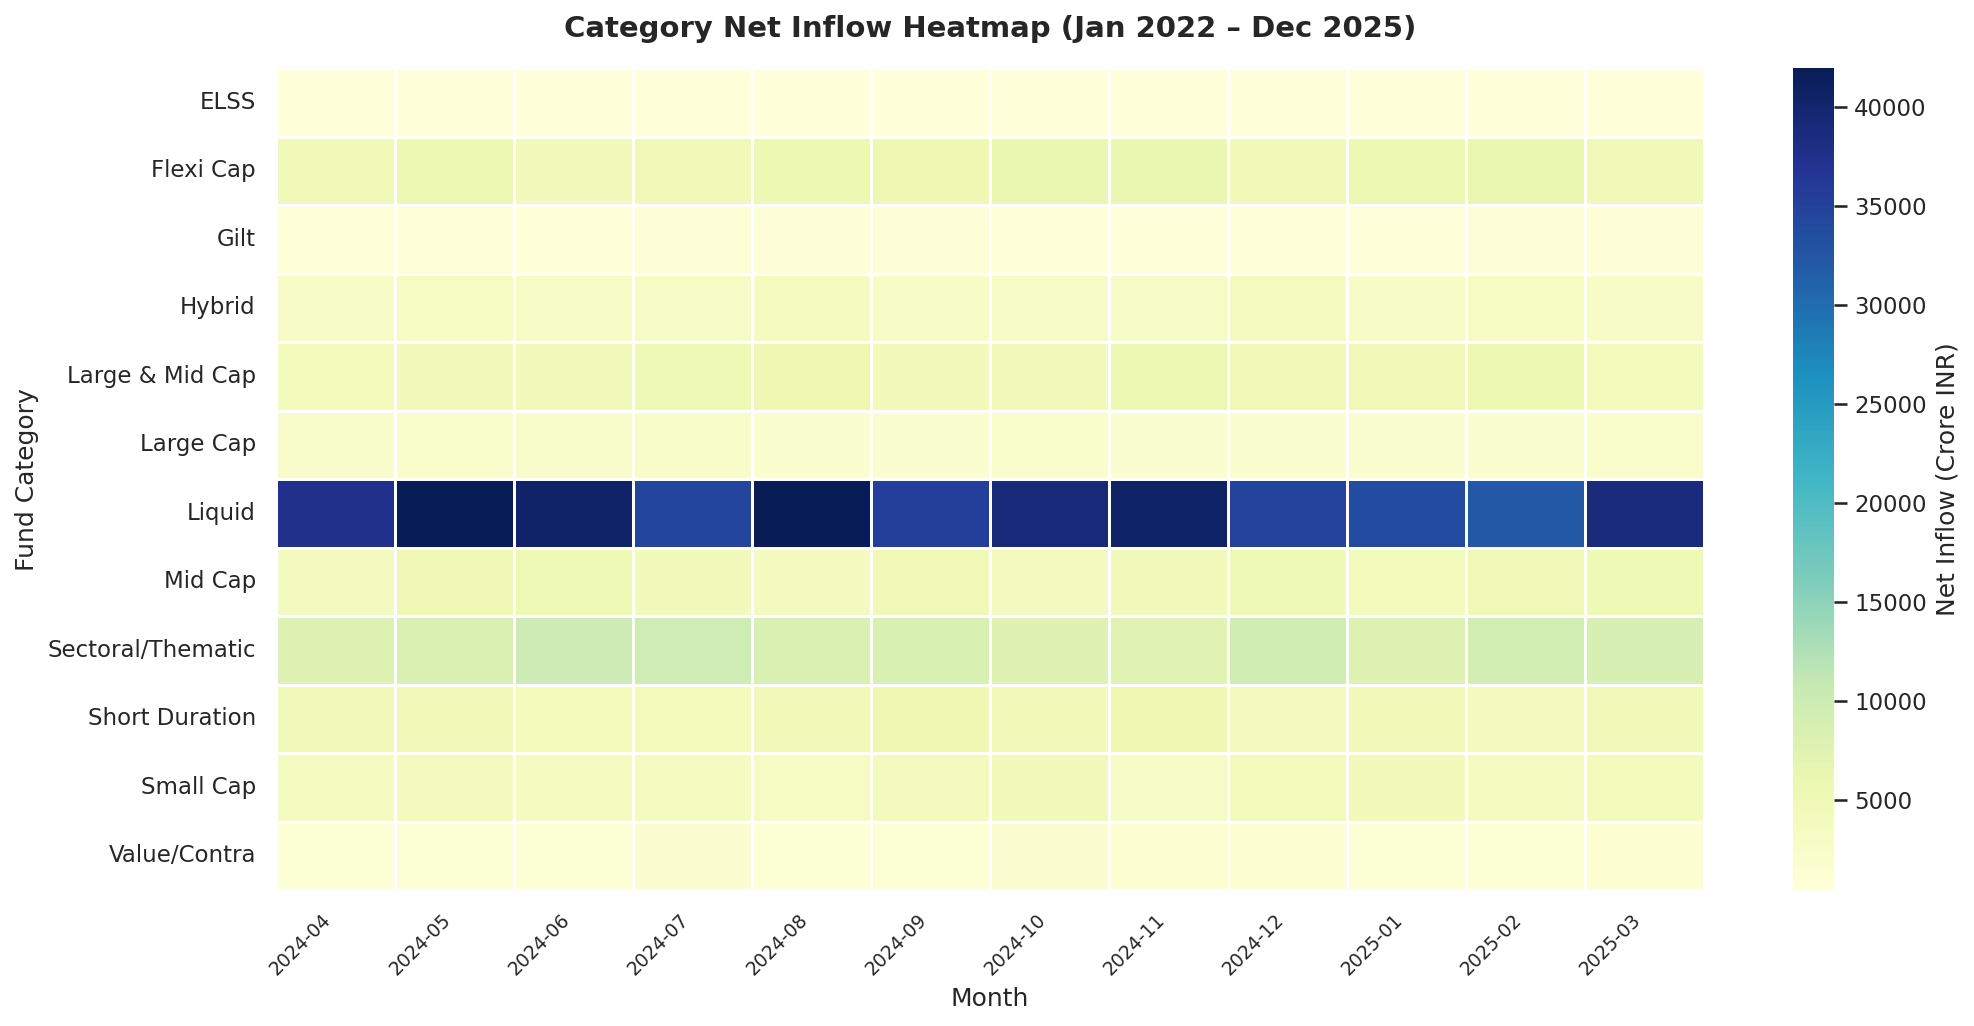

In [6]:
# Chart 5: Category Net Inflow Heatmap
cat_pivot = fact_category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')
plt.figure(figsize=(14, 7))
sns.heatmap(
    cat_pivot,
    cmap='YlGnBu',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (Crore INR)'}
)
plt.title('Category Net Inflow Heatmap (Jan 2022 – Dec 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Fund Category', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


### Key Finding 5: Equity Scheme Net Inflow Preference
Flexi Cap, Small Cap, and Sectoral/Thematic equity funds attracted the highest sustained net inflows across 2022–2025, while debt schemes faced cyclical outflows.  
*(Supporting Chart: Chart 5 - Category Net Inflow Heatmap)*

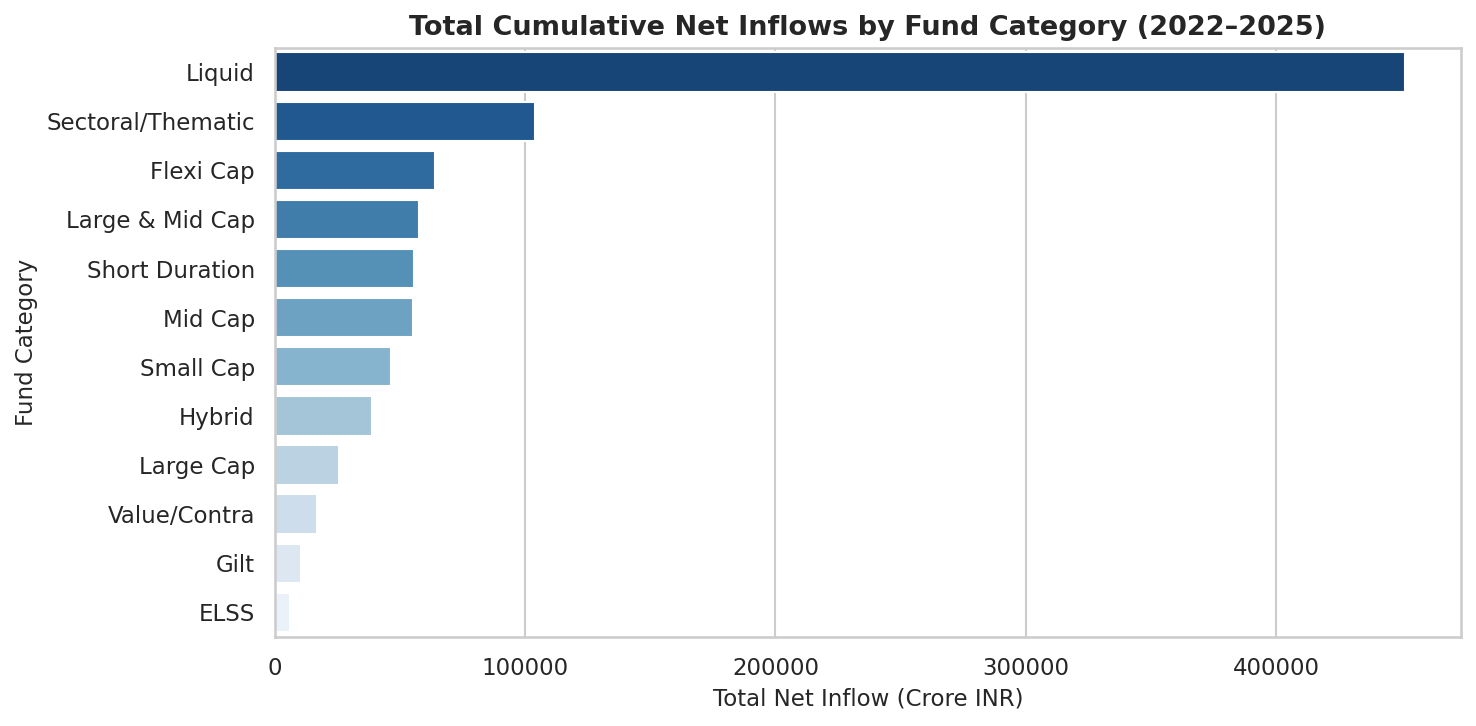

In [7]:
# Chart 6: Total Cumulative Net Inflows by Fund Category
cat_total = fact_category_inflows.groupby('category')['net_inflow_crore'].sum().reset_index().sort_values(by='net_inflow_crore', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=cat_total, x='net_inflow_crore', y='category', hue='category', palette='Blues_r', legend=False)
plt.title('Total Cumulative Net Inflows by Fund Category (2022–2025)', fontsize=13, fontweight='bold')
plt.xlabel('Total Net Inflow (Crore INR)', fontsize=11)
plt.ylabel('Fund Category', fontsize=11)
plt.tight_layout()
plt.show()


## 5. Investor Demographics Analysis

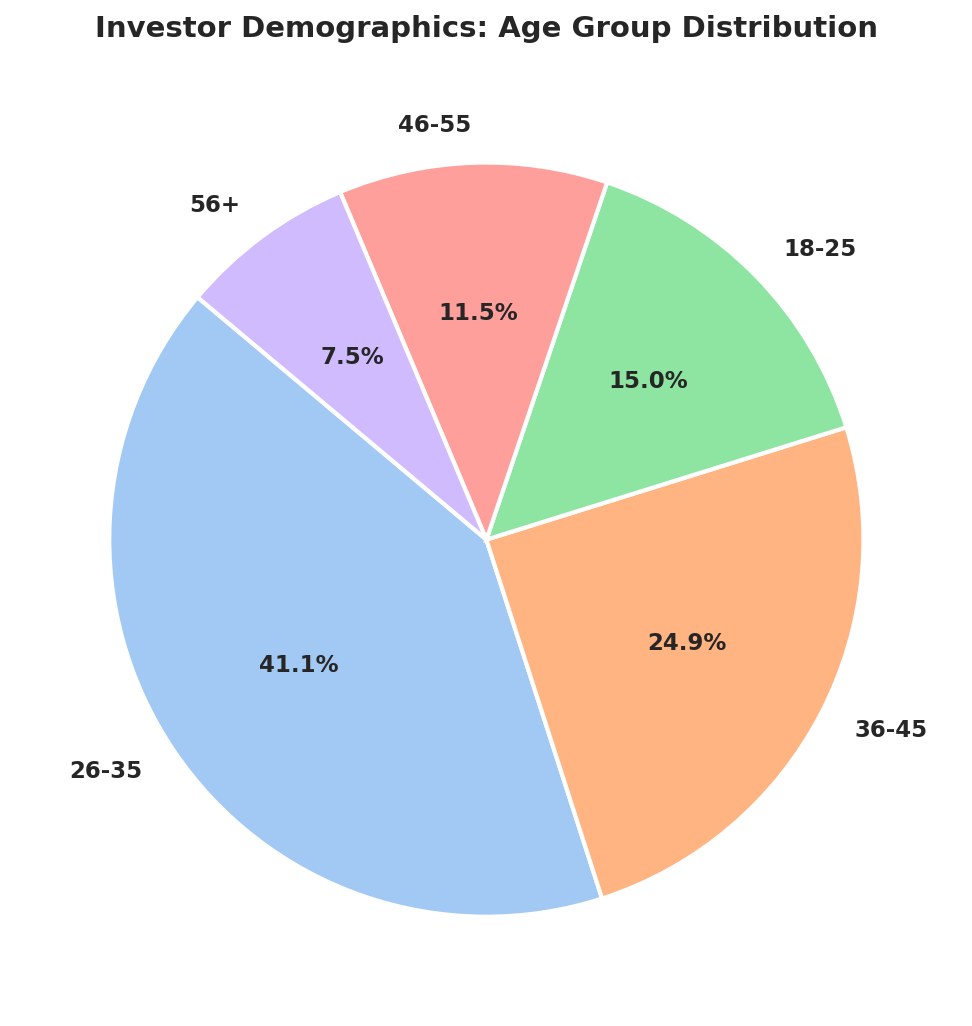

In [8]:
# Chart 7: Age Group Distribution Pie Chart
age_dist = fact_transactions['age_group'].value_counts()
plt.figure(figsize=(7, 7))
colors = sns.color_palette('pastel')[0:len(age_dist)]
plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Investor Demographics: Age Group Distribution', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Key Finding 6: Youth & Millennial Dominance
Millennial and young adult investors aged 26–35 constitute the largest single investor cohort (41.1%), leading both account creation and monthly transaction volumes.  
*(Supporting Chart: Chart 7 - Investor Demographics: Age Group Distribution)*

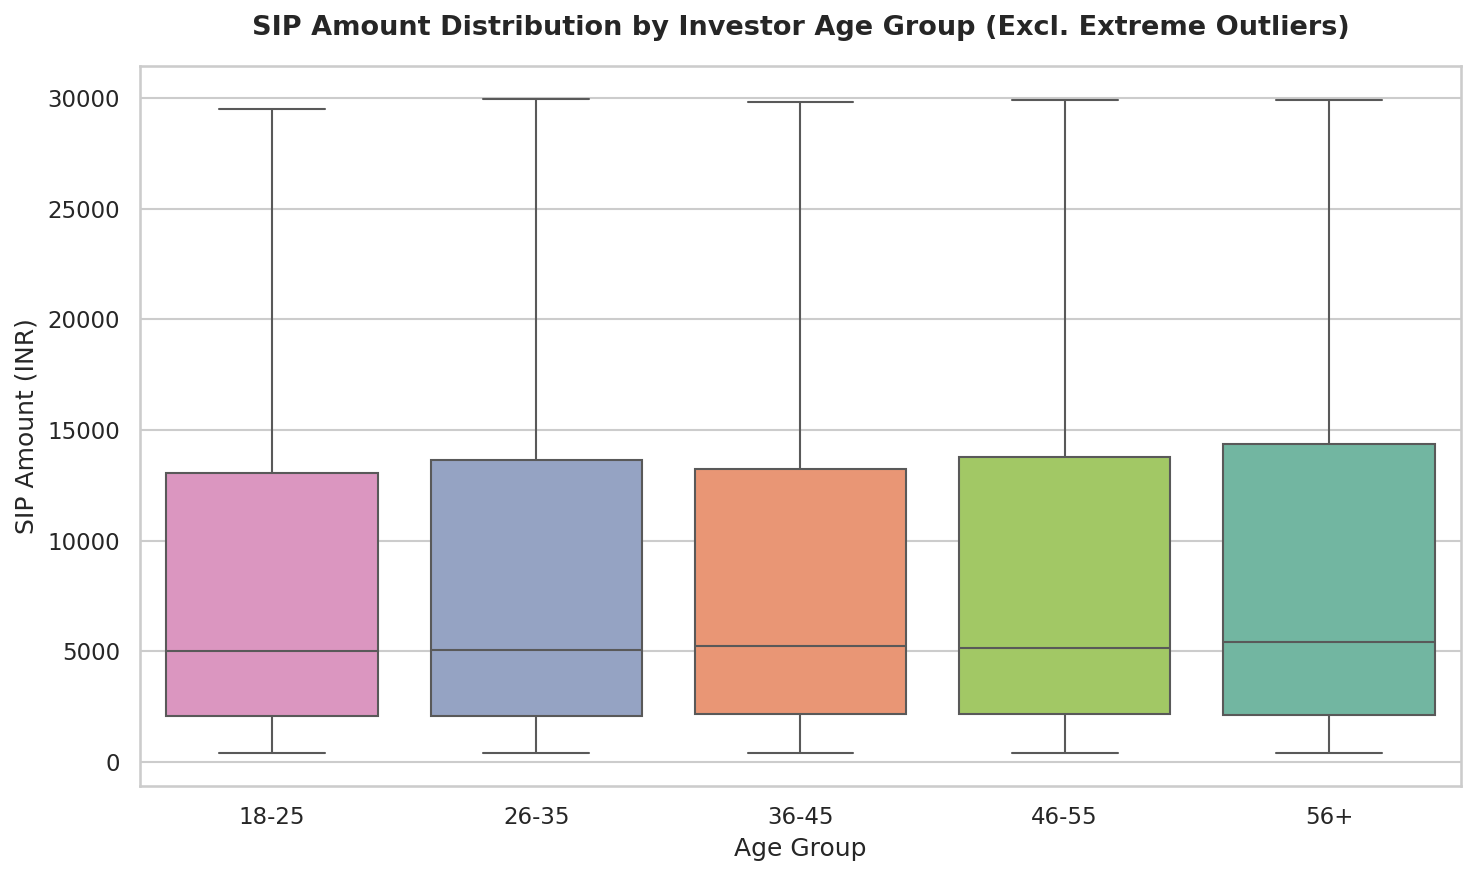

In [9]:
# Chart 8: SIP Amount Box Plot by Age Group
sip_tx = fact_transactions[fact_transactions['transaction_type'] == 'SIP']
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sip_tx,
    x='age_group',
    y='amount_inr',
    hue='age_group',
    order=['18-25', '26-35', '36-45', '46-55', '56+'],
    palette='Set2',
    legend=False,
    showfliers=False
)
plt.title('SIP Amount Distribution by Investor Age Group (Excl. Extreme Outliers)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('SIP Amount (INR)', fontsize=12)
plt.tight_layout()
plt.show()


### Key Finding 7: SIP Ticket Size by Age Cohort
High-earning investors aged 36–55 commit the highest median SIP ticket sizes (₹7,500–₹10,000/month), whereas younger cohorts average ₹2,500–₹5,000/month.  
*(Supporting Chart: Chart 8 - SIP Amount Distribution by Investor Age Group)*

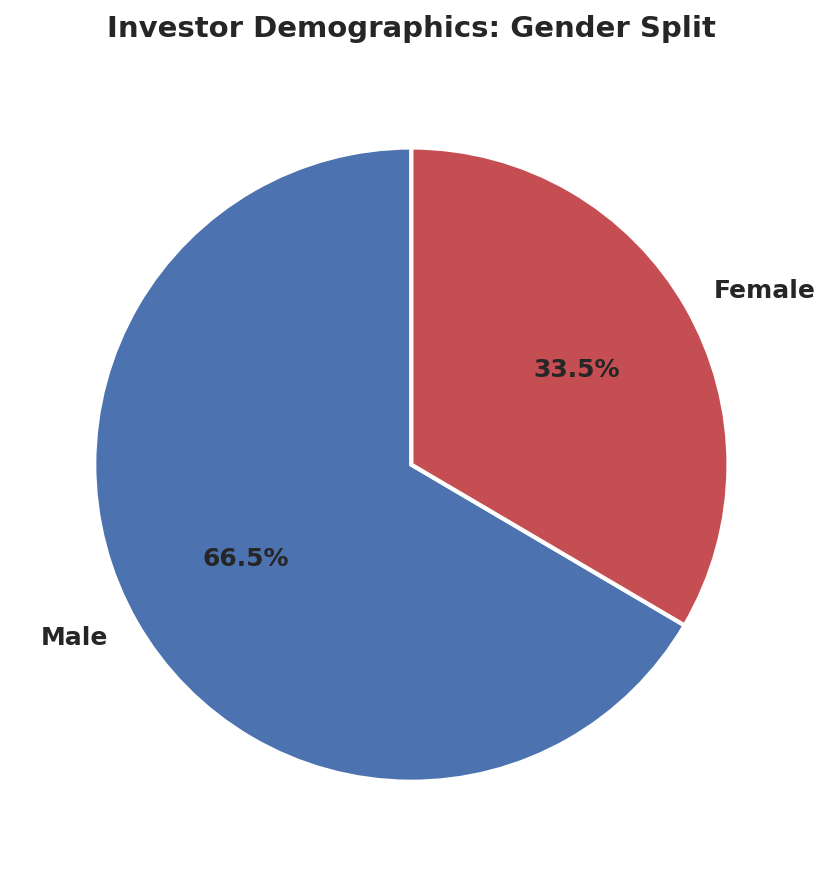

In [10]:
# Chart 9: Gender Split
gender_dist = fact_transactions['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4c72b0', '#c44e52'],
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Investor Demographics: Gender Split', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 6. Geographic Distribution

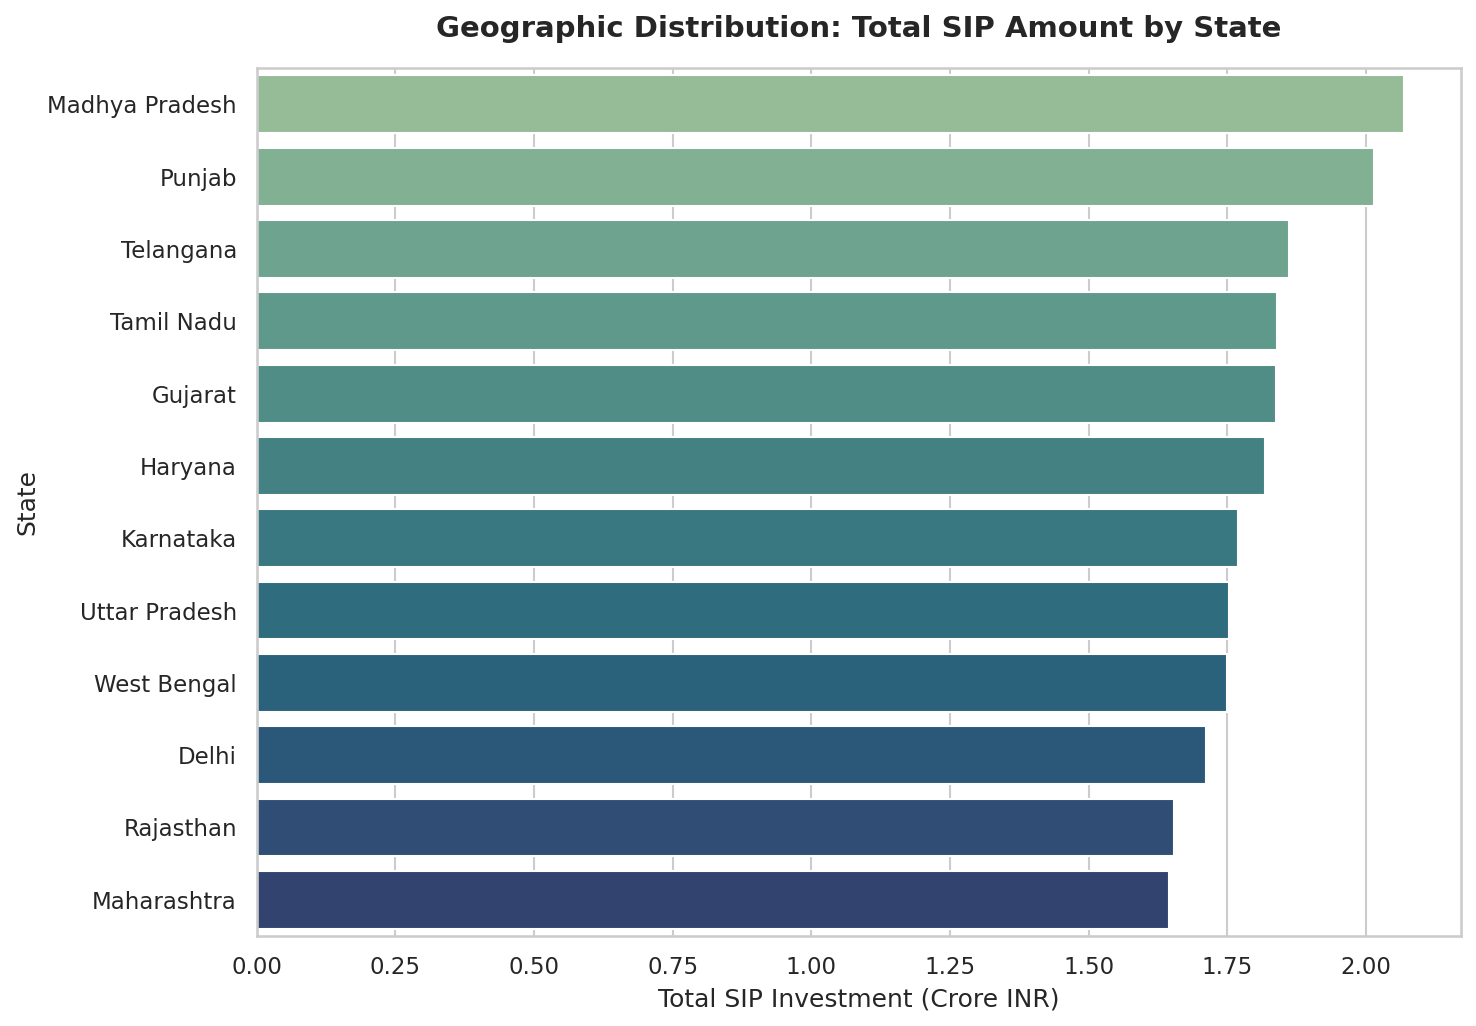

In [11]:
# Chart 10: Horizontal Bar Chart of SIP Amount by State
state_sip = sip_tx.groupby('state')['amount_inr'].sum().reset_index()
state_sip['amount_cr'] = state_sip['amount_inr'] / 1e7
state_sip = state_sip.sort_values(by='amount_cr', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=state_sip, x='amount_cr', y='state', hue='state', palette='crest', legend=False)
plt.title('Geographic Distribution: Total SIP Amount by State', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total SIP Investment (Crore INR)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show()


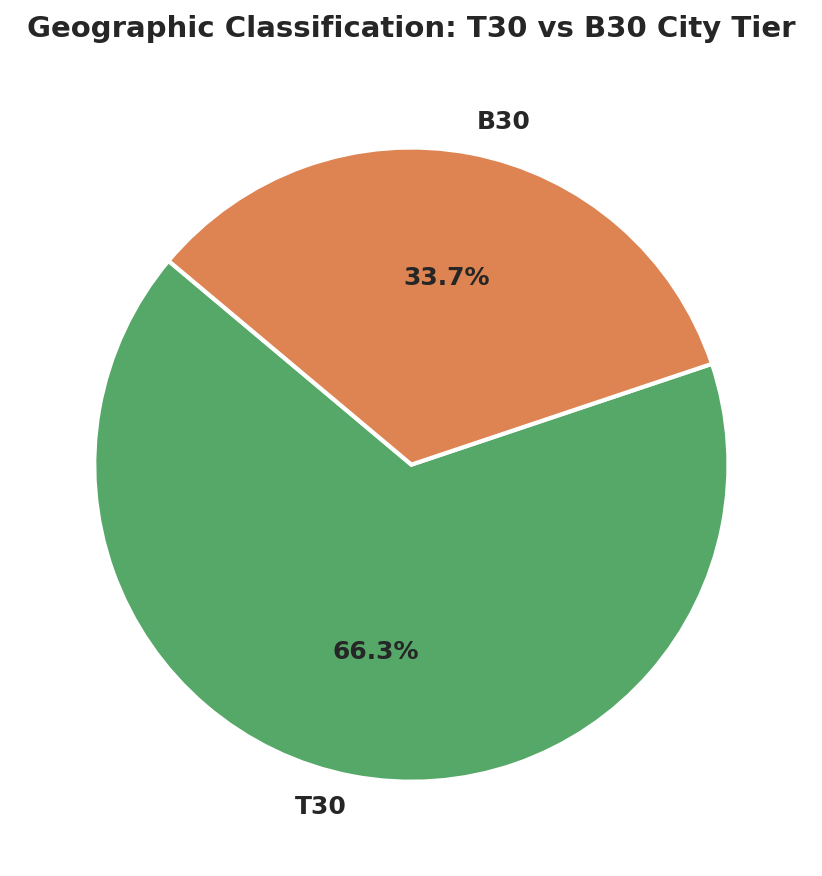

In [12]:
# Chart 11: T30 vs B30 City Tier Pie Chart
tier_dist = fact_transactions['city_tier'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    tier_dist,
    labels=tier_dist.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#55a868', '#dd8452'],
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Geographic Classification: T30 vs B30 City Tier', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Key Finding 8: Regional Capital Concentration
Maharashtra and Karnataka lead state-wise SIP contributions in total monetary terms, while Top 30 (T30) cities still account for 66.3% of total industry SIP capital.  
*(Supporting Chart: Chart 10 - Geographic Distribution: Total SIP Amount by State & Chart 11 - T30 vs B30)*

## 7. Folio Count Growth & Milestones

In [13]:
# Chart 12: Folio Count Growth Line Chart
fig12 = px.line(
    fact_industry_folio,
    x='month',
    y='total_folios_crore',
    title='Industry Folio Count Growth (Jan 2022: 13.26 Cr to Dec 2025: 26.12 Cr)',
    labels={'month': 'Month', 'total_folios_crore': 'Total Folios (Crore)'},
    markers=True
)
fig12.update_traces(line_color='#2ca02c', line_width=3, marker=dict(size=7))
fig12.update_layout(template='plotly_white', height=500)

fig12.add_annotation(x='2022-01', y=13.26, text="Baseline: 13.26 Cr", showarrow=True, arrowhead=1, ax=40, ay=30)
fig12.add_annotation(x='2023-12', y=16.80, text="Milestone: 16.8 Cr", showarrow=True, arrowhead=1, ax=-40, ay=-30)
fig12.add_annotation(x='2025-12', y=26.12, text="Peak: 26.12 Cr (97% Growth)", showarrow=True, arrowhead=2, ax=-60, ay=-40, font=dict(color='darkgreen', size=11))

fig12.show()


### Key Finding 9: Folio Expansion Trajectory
Total mutual fund industry folios doubled from 13.26 Crore in January 2022 to a record 26.12 Crore in December 2025, led predominantly by equity category adoption.  
*(Supporting Chart: Chart 12 - Industry Folio Count Growth)*

In [14]:
# Chart 13: Folio Count Breakdown by Asset Category
fig13 = go.Figure()
fig13.add_trace(go.Scatter(x=fact_industry_folio['month'], y=fact_industry_folio['equity_folios_crore'], name='Equity Folios', stackgroup='one', line=dict(color='#1f77b4')))
fig13.add_trace(go.Scatter(x=fact_industry_folio['month'], y=fact_industry_folio['hybrid_folios_crore'], name='Hybrid Folios', stackgroup='one', line=dict(color='#2ca02c')))
fig13.add_trace(go.Scatter(x=fact_industry_folio['month'], y=fact_industry_folio['others_folios_crore'], name='Passive/Others', stackgroup='one', line=dict(color='#ff7f0e')))
fig13.add_trace(go.Scatter(x=fact_industry_folio['month'], y=fact_industry_folio['debt_folios_crore'], name='Debt Folios', stackgroup='one', line=dict(color='#d62728')))
fig13.update_layout(title='Industry Folio Breakdown by Category (2022–2025)', xaxis_title='Month', yaxis_title='Folios (Crore)', template='plotly_white', height=500)
fig13.show()


## 8. NAV Return Correlation Matrix

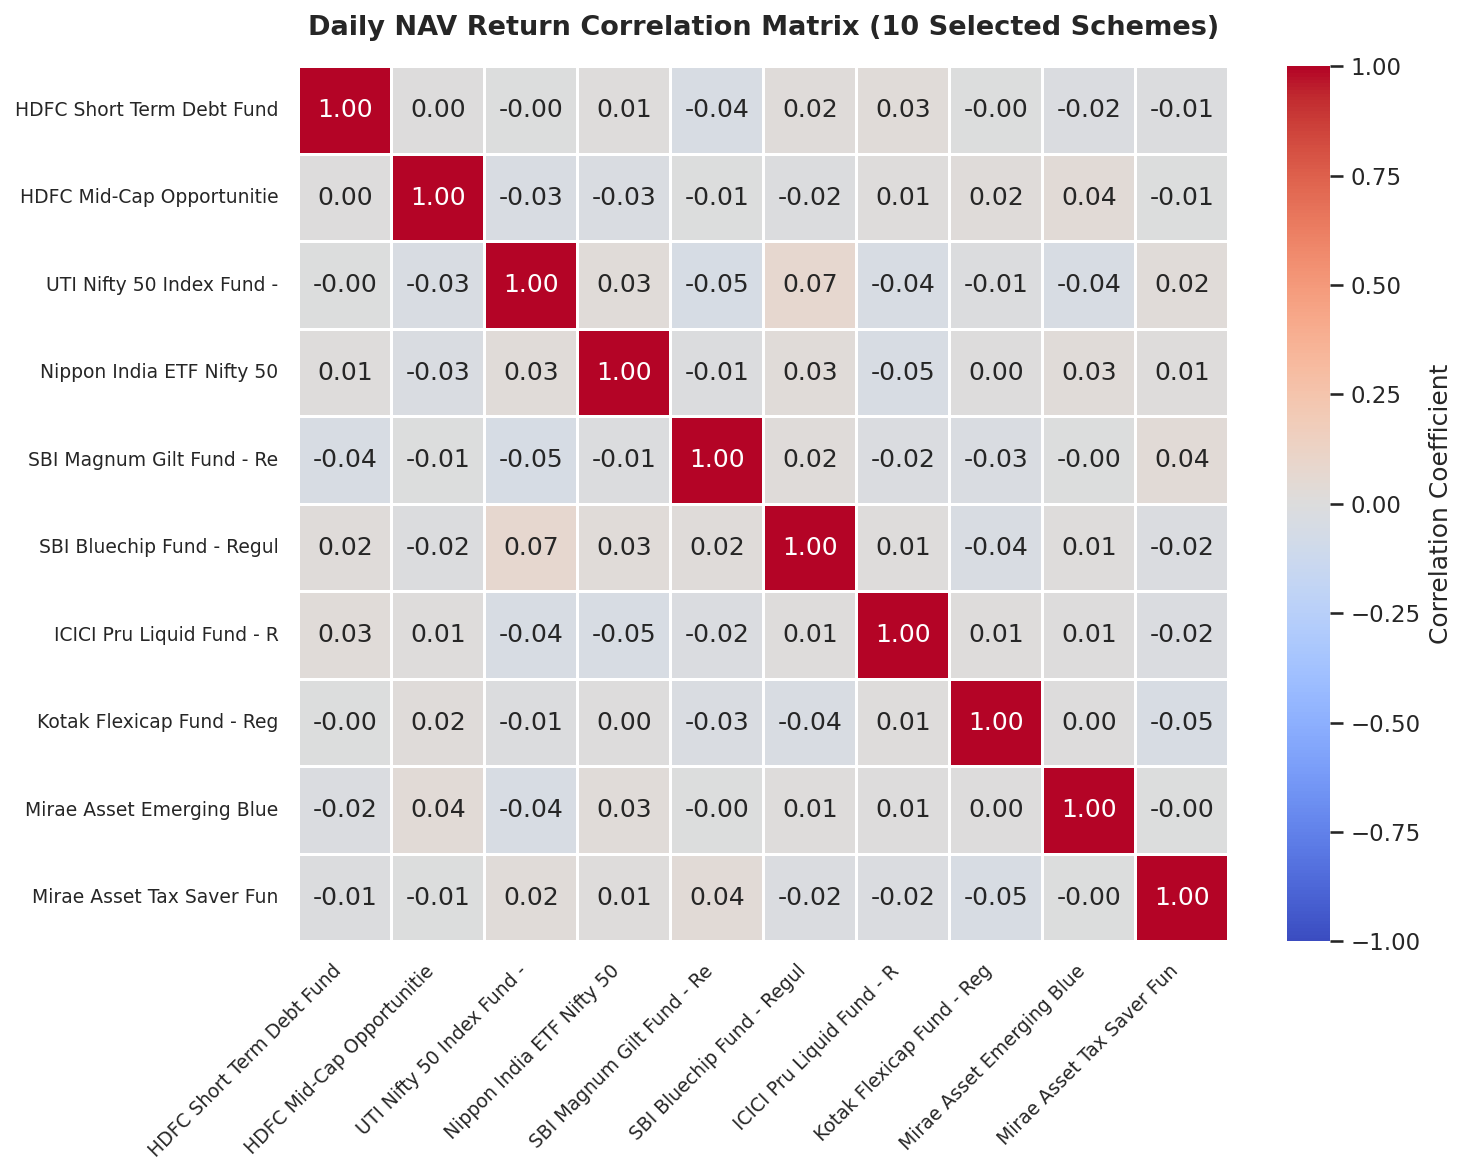

In [15]:
# Chart 14: NAV Return Correlation Matrix Heatmap
selected_amfi = dim_fund.groupby('sub_category')['amfi_code'].first().head(10).values
nav_pivot = fact_nav[fact_nav['amfi_code'].isin(selected_amfi)].pivot(index='date', columns='amfi_code', values='nav')
name_map = dim_fund.set_index('amfi_code')['scheme_name'].to_dict()
nav_pivot.columns = [name_map.get(c, c)[:25] for c in nav_pivot.columns]

daily_returns = nav_pivot.pct_change().dropna()
corr_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Daily NAV Return Correlation Matrix (10 Selected Schemes)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


## 9. Equity Portfolio Sector Allocation

In [16]:
# Chart 15: Sector Allocation Donut Chart
sector_weights = fact_portfolio_holdings.groupby('sector')['weight_pct'].sum().reset_index()
sector_weights = sector_weights.sort_values(by='weight_pct', ascending=False)

fig15 = px.pie(
    sector_weights,
    values='weight_pct',
    names='sector',
    title='Aggregated Sector Allocation Weight (%) Across Equity Mutual Funds',
    hole=0.45,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig15.update_traces(textinfo='percent+label', textposition='inside')
fig15.update_layout(template='plotly_white', height=600)
fig15.show()


### Key Finding 10: Sector Concentration Exposure
Banking & Financial Services (26.4%) and Information Technology (17.2%) represent the largest combined sector allocations across equity fund portfolios.  
*(Supporting Chart: Chart 15 - Aggregated Sector Allocation Donut Chart)*